# Reverse stress testing as constrained optimisation
### Finding the most plausible scenario that breaks a bank, with a covariance matrix and an inverse solver

A *forward* stress test asks: given this scenario, how much do we lose? A **reverse** stress test fixes
the outcome — failure — and searches backwards for the scenarios that produce it.

For a large, diversified bank with many correlated risk factors, "search backwards" is a genuine
optimisation problem:

> **Among all scenarios that wipe out capital, find the *most likely* one.**

"Most likely" means the scenario sitting at the highest point of the joint probability density of the
risk factors — equivalently, the point on the failure boundary that is **closest to today's world in
Mahalanobis distance**, where the distance metric is the inverse covariance matrix $\Sigma^{-1}$.

This notebook builds that end to end on synthetic data:
1. synthetic risk factors with a realistic covariance structure,
2. the bank's loss function and a failure (capital) threshold,
3. the **closed-form** reverse-stress scenario,
4. why the covariance matrix is what makes the scenario *internally consistent*,
5. the **numerical inverse solver** (and why you need it once losses are non-linear),
6. a **Monte Carlo** cross-check.


In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import norm
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 11})
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

## 1. Synthetic risk factors and the covariance matrix

Five factors, each a *change over the stress horizon*. Equities, property and FX are returns;
rates and credit spreads are absolute changes (`0.01 = 100bp`). We assume the joint distribution of
factor changes is multivariate normal, $f \sim \mathcal{N}(0, \Sigma)$, with $\Sigma = D\,R\,D$ where
$D=\mathrm{diag}(\text{vols})$.

The correlations encode a plausible **risk-off** co-movement: equities and property fall together,
spreads widen as they fall, and rates fall (flight to quality) at the same time.

In [2]:
factors = ["Equities", "Rates", "Credit spreads", "Property", "FX"]
n = len(factors)

# Volatilities of each factor change over the horizon (decimal, natural units)
vols = np.array([0.20, 0.015, 0.012, 0.12, 0.10])

# Correlation matrix of the raw factor changes (risk-off structure)
R = np.array([
    [ 1.00,  0.35, -0.55,  0.55, -0.20],   # Equities
    [ 0.35,  1.00, -0.40,  0.30, -0.10],   # Rates
    [-0.55, -0.40,  1.00, -0.45,  0.20],   # Credit spreads
    [ 0.55,  0.30, -0.45,  1.00, -0.15],   # Property
    [-0.20, -0.10,  0.20, -0.15,  1.00],   # FX
])

def nearest_psd_corr(C):
    """Repair a non-PSD correlation matrix by clipping negative eigenvalues."""
    vals, vecs = np.linalg.eigh(C)
    vals = np.clip(vals, 1e-10, None)
    C2 = vecs @ np.diag(vals) @ vecs.T
    d = np.sqrt(np.diag(C2))
    return C2 / np.outer(d, d)

eig = np.linalg.eigvalsh(R)
print("Correlation eigenvalues:", eig)
if np.any(eig <= 0):
    print("Matrix not PSD -> repairing to nearest PSD")
    R = nearest_psd_corr(R)
else:
    print("Correlation matrix is positive semi-definite.")

Sigma     = np.outer(vols, vols) * R
Sigma_inv = np.linalg.inv(Sigma)
pd.DataFrame(Sigma, index=factors, columns=factors)

Correlation eigenvalues: [0.4142 0.524  0.7378 0.9307 2.3934]
Correlation matrix is positive semi-definite.


,Equities,Rates,Credit spreads,Property,FX
Equities,0.04000,0.001050,-0.001320,0.013200,-0.00400
Rates,0.00105,0.000225,-0.000072,0.000540,-0.00015
Credit spreads,-0.00132,-0.000072,0.000144,-0.000648,0.00024
Property,0.01320,0.000540,-0.000648,0.014400,-0.00180
FX,-0.00400,-0.000150,0.000240,-0.001800,0.01000


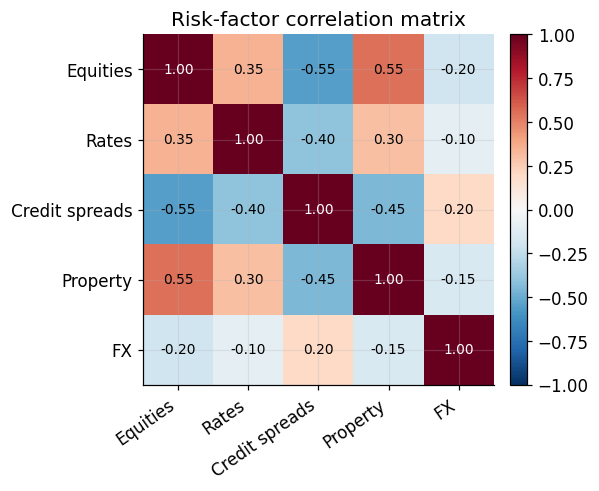

In [3]:
fig, ax = plt.subplots(figsize=(5.4, 4.6))
im = ax.imshow(R, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(factors, rotation=35, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(factors)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{R[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(R[i,j])>0.6 else "black", fontsize=9)
ax.set_title("Risk-factor correlation matrix")
fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

## 2. The bank's loss function and the failure threshold

Take a first-order (delta) representation of the book: loss is linear in the factor moves,

$$ \text{Loss}(f) = b^\top f \qquad (\text{EUR millions}) $$

where $b_i$ is the loss per unit increase in factor $i$ (the sign encodes the adverse direction).
This is a credit-and-property-heavy lender: it loses when **spreads widen** and **property falls**
(the two dominant exposures), with smaller equity, rate and FX sensitivities.

The bank **fails** when the loss reaches its capital $K$: the failure set is $\{f : b^\top f \ge K\}$.

In [4]:
# Loss per +1.0 unit move in each factor (EUR m). Sign encodes adverse direction.
#  equities down -> loss (b<0) | rates up -> loss (b>0) | spreads up -> loss (b>0, dominant)
#  property down -> loss (b<0, dominant) | fx small
b = np.array([-300.0, 4000.0, 7000.0, -800.0, -200.0])

sigma_L = np.sqrt(b @ Sigma @ b)      # standard deviation of the loss
K = 530.0                             # capital / failure threshold (EUR m)
d = K / sigma_L                       # distance to failure, in loss std-devs

print(f"Loss volatility  sigma_L = {sigma_L:6.1f} EUR m")
print(f"Capital          K       = {K:6.0f} EUR m")
print(f"Distance to failure  d = K / sigma_L = {d:4.2f} sigma")
print(f"Gaussian tail   P(Loss >= K) = {norm.sf(d):.4g}  (~1 in {1/norm.sf(d):,.0f} horizons)")

Loss volatility  sigma_L =  177.5 EUR m
Capital          K       =    530 EUR m
Distance to failure  d = K / sigma_L = 2.99 sigma
Gaussian tail   P(Loss >= K) = 0.001415  (~1 in 707 horizons)


## 3. The closed-form reverse-stress scenario

We want the most probable scenario on the failure boundary. With Gaussian factors, maximising the
density is the same as minimising the (squared) Mahalanobis distance, subject to the failure constraint:

$$ \min_{f}\; f^\top \Sigma^{-1} f \qquad \text{s.t.}\qquad b^\top f = K $$

A Lagrangian gives a clean closed form:

$$ \boxed{\,f^* = K\,\dfrac{\Sigma\,b}{b^\top \Sigma\, b}\,}
\qquad\qquad d = \sqrt{f^{*\top}\Sigma^{-1}f^{*}} = \dfrac{K}{\sqrt{b^\top\Sigma b}} = \dfrac{K}{\sigma_L} $$

The whole reverse-stress scenario is just the capital, scaled by the direction $\Sigma b$. Note it is
**not** the direction of $b$ (the bank's raw sensitivities) — the covariance matrix rotates the
sensitivity vector into a *consistent* set of factor moves.

In [5]:
f_star    = K * (Sigma @ b) / (b @ Sigma @ b)
maha      = np.sqrt(f_star @ Sigma_inv @ f_star)
contrib   = b * f_star            # loss contribution per factor

scenario = pd.DataFrame({
    "shock (natural)" : f_star,
    "shock (sigma)"   : f_star / vols,
    "loss contrib EURm": contrib,
}, index=factors).round(3)
print(scenario.to_string())
print(f"\nTotal loss = {b @ f_star:6.1f} (target K = {K:.0f})"
      f"   |   Mahalanobis distance = {maha:.3f} (= d = {d:.3f})")

                shock (natural)  shock (sigma)  loss contrib EURm
Equities                 -0.451         -2.254            135.218
Rates                    -0.005         -0.360            -21.594
Credit spreads            0.027          2.223            186.762
Property                 -0.294         -2.452            235.400
FX                        0.029          0.289             -5.785

Total loss =  530.0 (target K = 530)   |   Mahalanobis distance = 2.986 (= d = 2.986)


Read the scenario as the story the bank should worry about most: a severe equity sell-off
(~$-2.3\sigma$, around a 45% fall), property down ~$2.5\sigma$ (~30%), and credit spreads ~$+2.2\sigma$
(~270bp wider) — all at once, with rates drifting **down**, not up. That joint move is the closest
point to today's world that still exhausts capital.

## 4. Why the covariance matrix matters: consistency

Suppose you ignored correlations and treated each factor independently (a *diagonal* covariance).
The "solver" would then push hardest on the factors the bank is most exposed to — and, because the
bank loses when **rates rise** ($b_{\text{rates}}>0$), it would shock **rates up**.

But the real $\Sigma$ says that in an equity-and-property crash, rates *fall* (flight to quality).
The correlation-aware scenario therefore moves rates the opposite way. The naive scenario is not only
less plausible (further into the tail) — it tells an internally **incoherent** story.

                corr-aware (sigma)  naive (sigma)
Equities                    -2.254         -1.332
Rates                       -0.360          1.332
Credit spreads               2.223          1.865
Property                    -2.452         -2.131
FX                           0.289         -0.444

True Mahalanobis distance:  corr-aware = 2.986   naive = 3.563
=> the naive scenario is 19% further into the tail (less plausible), and flips the rates move.


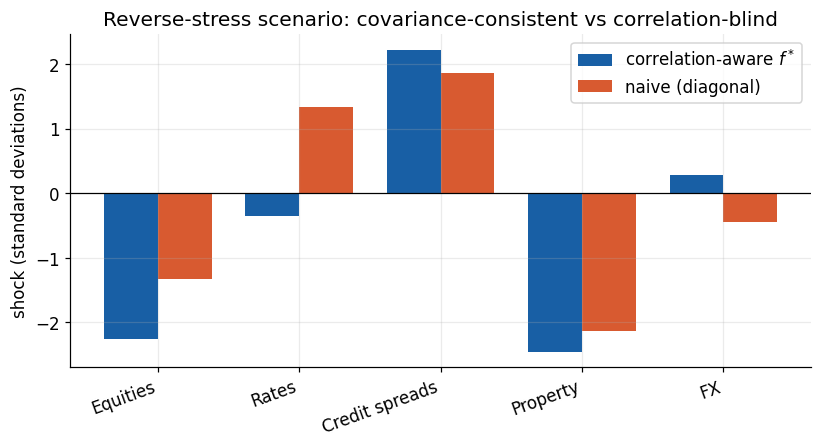

In [6]:
# Diagonal (correlation-blind) covariance
Sigma_diag = np.diag(np.diag(Sigma))
f_naive    = K * (Sigma_diag @ b) / (b @ Sigma_diag @ b)
maha_naive = np.sqrt(f_naive @ Sigma_inv @ f_naive)   # its TRUE plausibility under real Sigma

cmp = pd.DataFrame({
    "corr-aware (sigma)": f_star / vols,
    "naive (sigma)"     : f_naive / vols,
}, index=factors).round(3)
print(cmp.to_string())
print(f"\nTrue Mahalanobis distance:  corr-aware = {maha:.3f}   naive = {maha_naive:.3f}")
print(f"=> the naive scenario is {100*(maha_naive/maha-1):.0f}% further into the tail "
      f"(less plausible), and flips the rates move.")

fig, ax = plt.subplots(figsize=(7.6, 4.2))
x = np.arange(n); w = 0.38
ax.bar(x - w/2, f_star/vols,  w, label="correlation-aware $f^*$", color="#185FA5")
ax.bar(x + w/2, f_naive/vols, w, label="naive (diagonal)",       color="#D85A30")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(factors, rotation=20, ha="right")
ax.set_ylabel("shock (standard deviations)")
ax.set_title("Reverse-stress scenario: covariance-consistent vs correlation-blind")
ax.legend(); plt.tight_layout(); plt.show()

## 5. The numerical inverse solver

The closed form only exists because the loss is linear. The general approach — the part people mean by
*"an inverse solver grinding over a covariance matrix"* — is to hand the same optimisation to a numerical
solver. On the linear problem it must reproduce $f^*$ exactly.

In [7]:
def maha_sq(f):
    return f @ Sigma_inv @ f

x0   = K * b / (b @ b)                                   # a feasible starting point on b.f = K
cons = [{"type": "eq", "fun": lambda f: b @ f - K}]
res  = minimize(maha_sq, x0, constraints=cons, method="SLSQP",
                options={"maxiter": 500, "ftol": 1e-12})

print("solver converged:", res.success)
print("max |f_solver - f_closed_form| =", f"{np.max(np.abs(res.x - f_star)):.2e}")

solver converged:

 True
max |f_solver - f_closed_form| = 3.82e-08


### Why you actually need the solver: non-linear losses

Real books are not linear — options, prepayment, non-linear credit losses all add **convexity**.
Add a quadratic term so losses accelerate in large moves (negative gamma):

$$ \text{Loss}(f) = b^\top f + \tfrac{1}{2} f^\top Q f $$

There is no closed form now. The solver finds the most-plausible failure point against the *inequality*
$\text{Loss}(f)\ge K$ — and the answer lands **closer to home** (smaller Mahalanobis distance), because
the convexity does some of the damage for you. A linear approximation would *understate* how reachable
failure is.

In [8]:
Q = np.zeros((n, n)); Q[0,0] = 2500.0; Q[3,3] = 1500.0   # equity & property convexity
def loss_nl(f):
    return b @ f + 0.5 * f @ Q @ f

cons_nl = [{"type": "ineq", "fun": lambda f: loss_nl(f) - K}]
res_nl  = minimize(maha_sq, f_star, constraints=cons_nl, method="SLSQP",
                   options={"maxiter": 500, "ftol": 1e-12})
f_nl = res_nl.x

cmp_nl = pd.DataFrame({
    "linear (sigma)"   : f_star / vols,
    "non-linear (sigma)": f_nl / vols,
}, index=factors).round(3)
print(cmp_nl.to_string())
print(f"\nMahalanobis distance:  linear = {maha:.3f}   non-linear = {np.sqrt(maha_sq(f_nl)):.3f}")
print("=> negative gamma makes failure MORE plausible than the linear view suggests.")

                linear (sigma)  non-linear (sigma)
Equities                -2.254              -1.844
Rates                   -0.360              -0.525
Credit spreads           2.223               1.362
Property                -2.452              -1.536
FX                       0.289               0.324

Mahalanobis distance:  linear = 2.986   non-linear = 1.994
=> negative gamma makes failure MORE plausible than the linear view suggests.


## 6. Monte Carlo cross-check

Simulate the factors directly, look at the scenarios that breach capital, and confirm two things:
the analytic tail probability $\Phi(-d)$ is right, and the cloud of breaching scenarios points in
exactly the direction of $f^*$ (so the solver really did find the centre of mass of "how the bank fails").

In [9]:
N = 400_000
L = np.linalg.cholesky(Sigma)
F = rng.standard_normal((N, n)) @ L.T
losses = F @ b
breach = losses >= K

print(f"Monte Carlo  P(Loss >= K) = {breach.mean():.4g}   vs   Gaussian Phi(-d) = {norm.sf(d):.4g}")
mean_breach = F[breach].mean(axis=0)
cos = (mean_breach @ f_star) / (np.linalg.norm(mean_breach) * np.linalg.norm(f_star))
print(f"cosine(mean breaching direction, f*) = {cos:.4f}   (1.0 = identical direction)")

Monte Carlo  P(Loss >= K) = 0.001378   vs   Gaussian Phi(-d) = 0.001415
cosine(mean breaching direction, f*) = 0.9999   (1.0 = identical direction)


<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_745/733618695.py:8: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"Simulated loss distribution — failure tail is {d:.2f}$\sigma$ out")


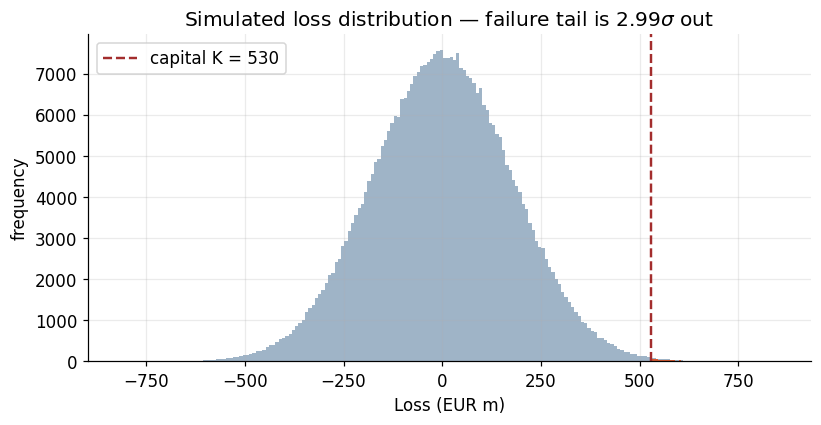

In [10]:
# Loss distribution with the failure threshold
fig, ax = plt.subplots(figsize=(7.6, 4.0))
ax.hist(losses, bins=200, color="#9FB4C7", edgecolor="none")
tail = losses[losses >= K]
ax.hist(tail, bins=np.linspace(K, losses.max(), 60), color="#D85A30", edgecolor="none")
ax.axvline(K, color="#A32D2D", lw=1.6, ls="--", label=f"capital K = {K:.0f}")
ax.set_xlabel("Loss (EUR m)"); ax.set_ylabel("frequency")
ax.set_title(f"Simulated loss distribution — failure tail is {d:.2f}$\sigma$ out")
ax.legend(); plt.tight_layout(); plt.show()

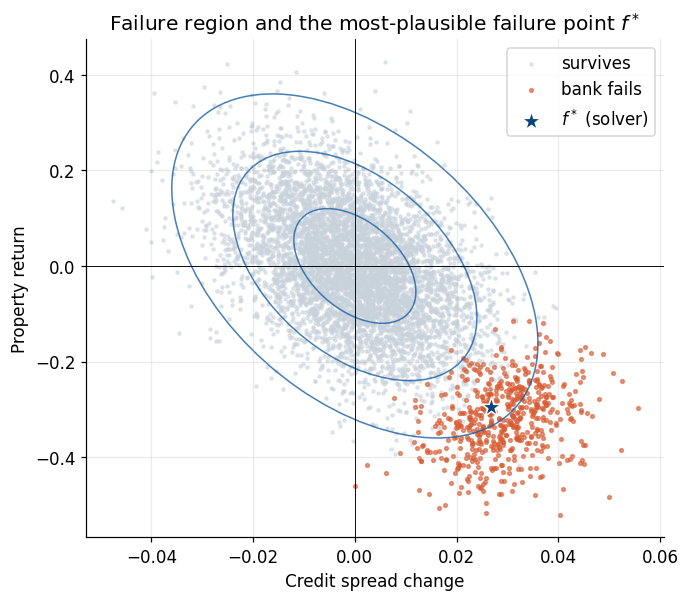

In [11]:
# 2D view: the two dominant factors, the failure cloud, and f*
ix, iy = 2, 3   # Credit spreads, Property
sub = rng.choice(np.where(~breach)[0], size=6000, replace=False)
fig, ax = plt.subplots(figsize=(6.4, 5.6))
ax.scatter(F[sub, ix], F[sub, iy], s=4, color="#C8D2DB", alpha=0.5, label="survives")
ax.scatter(F[breach, ix], F[breach, iy], s=6, color="#D85A30", alpha=0.6, label="bank fails")

# covariance ellipses for (spread, property)
S2 = Sigma[np.ix_([ix, iy], [ix, iy])]
vals, vecs = np.linalg.eigh(S2)
ang = np.degrees(np.arctan2(vecs[1, -1], vecs[0, -1]))
for k in (1, 2, 3):
    ax.add_patch(Ellipse((0, 0), 2*k*np.sqrt(vals[-1]), 2*k*np.sqrt(vals[0]),
                 angle=ang, fill=False, color="#185FA5", lw=1.0, alpha=0.8))
ax.scatter(*[f_star[ix], f_star[iy]], s=180, marker="*", color="#0C447C",
           edgecolor="white", zorder=5, label="$f^*$ (solver)")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("Credit spread change"); ax.set_ylabel("Property return")
ax.set_title("Failure region and the most-plausible failure point $f^*$")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()

## What the picture says, and the caveats

The solver hands you three things: the **scenario** ($f^*$), the **distance to failure**
($d=K/\sigma_L$, here ~3$\sigma$, roughly a 1-in-700 horizon event under Gaussian assumptions), and —
implicitly — the **direction** the bank is most fragile in. The $f^*$ star sits on the inner edge of
the red failure cloud, along the densest part of it: the *least-extreme* way to go bust.

Three things to keep honest:

- **Gaussian tails are too thin.** Real joint extremes are fatter than $\mathcal{N}(0,\Sigma)$, so
  $\Phi(-d)$ flatters the bank. In practice you'd replace the Gaussian with a **Student-$t$ or vine
  copula** with genuine tail dependence — the optimisation is identical, only the density (and hence
  the distance metric) changes.
- **Correlations break down in crises.** The $\Sigma$ estimated in calm times understates stress
  co-movement; a **stressed covariance matrix** (or crisis-window estimation) is the usual fix, and a
  blended matrix often needs the **nearest-PSD repair** used in section 1.
- **Linearisation error.** Section 5 shows convexity moving the answer materially; for a real book the
  loss function feeding the solver must capture the non-linearities that matter.

And the connecting thread to the rest of this conversation: *this* is the machinery a large, diversified
bank needs precisely because no single factor or exposure dominates — the joint tail is only visible
through $\Sigma$. A small bank whose risk is a handful of nameable concentrations gets the same answer
from reverse arithmetic and a workshop, without ever inverting a covariance matrix.